# 2 · Evaluación del Piloto Baseline

**TFG:** Reconocimiento de Emociones Musicales (Fine-Tuning vs Zero-Shot)

**Objetivo:** Analizar los resultados del entrenamiento piloto (SimpleCNN, 200 tracks, 5 epochs) sin re-entrenar.

## §1 — Curvas de Entrenamiento

Curvas: c:\Users\Usuario\OneDrive - UNIVERSIDAD DE MURCIA\Escritorio\CIENCIA DE DATOS RUBEN\CUARTO\TFG_Emociones\figures\training_curves.png


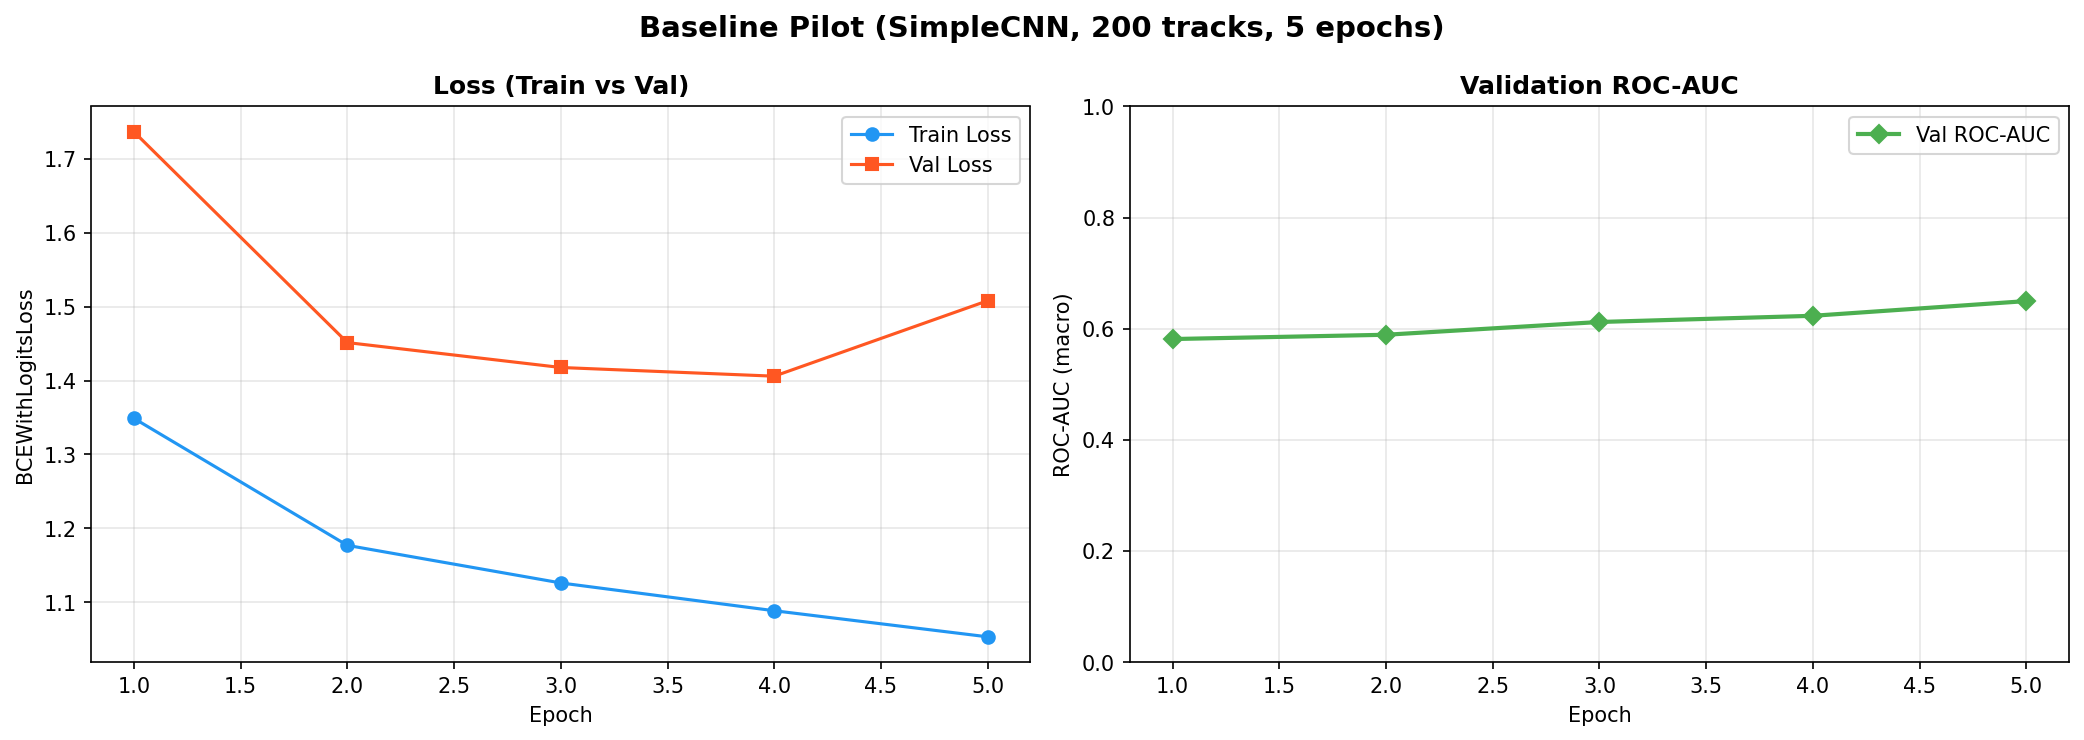

In [2]:
import sys
from pathlib import Path
from IPython.display import Image, display

PROJECT_ROOT = Path.cwd().parent
sys.path.insert(0, str(PROJECT_ROOT / 'src'))

curves_path = PROJECT_ROOT / 'figures' / 'training_curves.png'
print(f'Curvas: {curves_path}')
display(Image(filename=str(curves_path), width=900))

In [3]:
# Extraer historia del checkpoint
import torch

model_path = PROJECT_ROOT / 'models' / 'baseline_pilot.pth'
checkpoint = torch.load(model_path, map_location='cpu', weights_only=False)

history = checkpoint['history']
print(f"{'Epoch':>6}  {'Train Loss':>12}  {'Val Loss':>10}  {'Val AUC':>10}")
print('-' * 45)
for i in range(len(history['train_loss'])):
    print(f"{i+1:>6}  {history['train_loss'][i]:>12.4f}  {history['val_loss'][i]:>10.4f}  {history['val_auc'][i]:>10.4f}")
print(f"\nMejor Val AUC: {max(history['val_auc']):.4f}")

 Epoch    Train Loss    Val Loss     Val AUC
---------------------------------------------
     1        1.3488      1.7369      0.5814
     2        1.1768      1.4514      0.5892
     3        1.1258      1.4176      0.6121
     4        1.0882      1.4059      0.6233
     5        1.0529      1.5081      0.6498

Mejor Val AUC: 0.6498


## §2 — Cargar Modelo

In [4]:
from models import SimpleCNN

# Recuperar config del checkpoint
label_list = checkpoint['label_list']
n_classes = checkpoint['n_classes']
print(f'Clases: {n_classes}')
print(f'Etiquetas: {label_list[:10]} ...')

# Instanciar y cargar pesos
model = SimpleCNN(n_classes=n_classes, in_channels=1)
model.load_state_dict(checkpoint['model_state_dict'])
model.eval()

total_params = sum(p.numel() for p in model.parameters())
print(f'Modelo cargado: SimpleCNN ({total_params:,} params)')
print(f'Modo: evaluacion (model.eval())')

Clases: 59
Etiquetas: ['action', 'adventure', 'advertising', 'ambiental', 'background', 'ballad', 'calm', 'children', 'christmas', 'commercial'] ...
Modelo cargado: SimpleCNN (403,963 params)
Modo: evaluacion (model.eval())


## §3 — Inferencia de Prueba

In [5]:
import random
import ast
import numpy as np
import pandas as pd
import torch
from audio_utils import AudioPreprocessor

# 1. Configuración de rutas y carga de datos
# Asegúrate de que PROJECT_ROOT esté definido previamente en tu notebook
pilot_df = pd.read_csv(PROJECT_ROOT / 'data' / 'pilot_tracks.tsv', sep='\t')
pilot_df['tags'] = pilot_df['tags'].apply(ast.literal_eval)

AUDIO_DIR = PROJECT_ROOT / 'data' / 'audio'

# Filtrar tracks con audio disponible
pilot_df = pilot_df[
    pilot_df['path'].apply(lambda p: (AUDIO_DIR / p).exists())
].reset_index(drop=True)

# 2. Configuración del preprocesador y dispositivo
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model.to(device)
model.eval()

preprocessor = AudioPreprocessor(target_sr=32000, duration=30.0)

# 3. Selección de muestra y ejecución de inferencia múltiple
random.seed(99)
n_ejemplos = 10
# Seleccionamos 10 índices al azar
sample_indices = random.sample(range(len(pilot_df)), n_ejemplos)

print(f"Iniciando auditoría de {n_ejemplos} ejemplos aleatorios...\n")

for count, idx in enumerate(sample_indices, 1):
    row = pilot_df.iloc[idx]
    audio_path = AUDIO_DIR / row['path']
    real_tags = row['tags']
    
    try:
        # Procesar audio
        y = preprocessor.load_audio(str(audio_path))
        y = preprocessor._fix_length(y)
        y = preprocessor._normalize(y)
        log_mel = preprocessor.get_melspec(y)

        # Convertir a tensor batch y mover a dispositivo
        x = torch.tensor(log_mel, dtype=torch.float32).unsqueeze(0).unsqueeze(0).to(device)
        
        # Inferencia
        with torch.no_grad():
            logits = model(x)
            probs = torch.sigmoid(logits).squeeze()  # (59,)

        # Top 10 predicciones
        top10_idx = torch.argsort(probs, descending=True)[:10]

        # --- Visualización del ejemplo ---
        print(f"EJEMPLO {count}: {row['path']} (ID: {row['track_id']})")
        print(f"{'='*55}")
        print(f"   TOP 10 EMOCIONES PREDICHAS")
        print(f"{'='*55}")
        print(f"   {'#':>3}   {'Etiqueta':<22}   {'Prob':>7}   {'Real':>6}")
        print(f"   {'-'*3}   {'-'*22}   {'-'*7}   {'-'*6}")
        
        for rank, i in enumerate(top10_idx, 1):
            tag = label_list[i]
            prob = probs[i].item()
            is_real = 'SI' if tag in real_tags else ''
            marker = ' <<' if tag in real_tags else ''
            print(f"   {rank:>3}   {tag:<22}   {prob:>6.1%}   {is_real:>6}{marker}")

        print(f"\n   Etiquetas reales: {real_tags}")
        hits = sum(1 for t in real_tags if t in [label_list[i] for i in top10_idx])
        print(f"   Aciertos en top-10: {hits}/{len(real_tags)}")
        print(f"{'—'*55}\n")

    except Exception as e:
        print(f"Error procesando track {row['path']}: {e}\n")

print("Auditoría finalizada.")

Iniciando auditoría de 10 ejemplos aleatorios...



c:\Users\Usuario\miniconda3\envs\gpu_env\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


EJEMPLO 1: 80/592180.mp3 (ID: track_0592180)
   TOP 10 EMOCIONES PREDICHAS
     #   Etiqueta                    Prob     Real
   ---   ----------------------   -------   ------
     1   christmas                 68.1%         
     2   holiday                   63.6%         
     3   melancholic               63.2%         
     4   movie                     63.2%       SI <<
     5   uplifting                 62.8%         
     6   dark                      62.3%         
     7   trailer                   61.6%         
     8   melodic                   61.0%         
     9   slow                      58.4%         
    10   adventure                 55.3%         

   Etiquetas reales: ['movie']
   Aciertos en top-10: 1/1
———————————————————————————————————————————————————————

EJEMPLO 2: 13/1269813.mp3 (ID: track_1269813)
   TOP 10 EMOCIONES PREDICHAS
     #   Etiqueta                    Prob     Real
   ---   ----------------------   -------   ------
     1   horror           

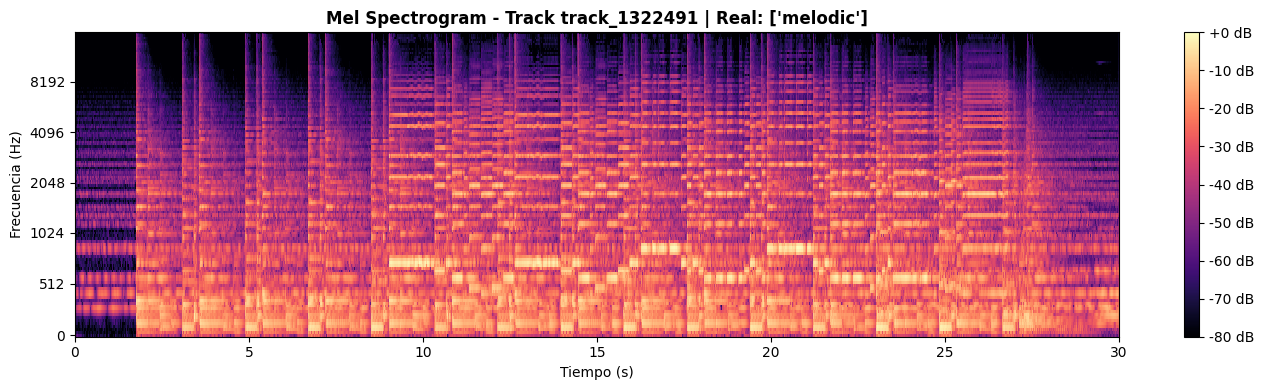

In [6]:
# Visualizar espectrograma de la cancion evaluada
import matplotlib.pyplot as plt
import librosa.display

fig, ax = plt.subplots(figsize=(14, 4))
librosa.display.specshow(
    log_mel, sr=32000, hop_length=320,
    x_axis='time', y_axis='mel', ax=ax
)
ax.set_title(f'Mel Spectrogram - Track {row["track_id"]} | Real: {real_tags}',
             fontsize=12, fontweight='bold')
ax.set_xlabel('Tiempo (s)')
ax.set_ylabel('Frecuencia (Hz)')
fig.colorbar(ax.collections[0], ax=ax, format='%+2.0f dB')
plt.tight_layout()
plt.show()

In [7]:
import torch
import numpy as np
from sklearn.metrics import roc_auc_score, label_ranking_average_precision_score
from tqdm import tqdm

# 1. Configuración inicial
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model.to(device)
model.eval()

y_true_list = []
y_score_list = []

print("Evaluando las 200 canciones con SimpleCNN...")

# 2. Bucle de inferencia sobre todo el piloto
for idx, row in tqdm(pilot_df.iterrows(), total=len(pilot_df)):
    audio_path = AUDIO_DIR / row['path']
    real_tags = row['tags']
    
    try:
        # Preprocesamiento de audio
        y = preprocessor.load_audio(str(audio_path))
        y = preprocessor._fix_length(y)
        y = preprocessor._normalize(y)
        log_mel = preprocessor.get_melspec(y)
        x = torch.tensor(log_mel, dtype=torch.float32).unsqueeze(0).unsqueeze(0).to(device)
        
        # Inferencia
        with torch.no_grad():
            logits = model(x)
            probs = torch.sigmoid(logits).squeeze().cpu().numpy()
            
        # Crear vector multi-hot para las etiquetas reales (y_true)
        y_true = np.zeros(len(label_list))
        for tag in real_tags:
            if tag in label_list:
                y_true[label_list.index(tag)] = 1
                
        y_true_list.append(y_true)
        y_score_list.append(probs)
        
    except Exception as e:
        pass # Ignorar canciones corruptas si las hay

# Convertir a matrices Numpy
y_true_np = np.array(y_true_list)
y_score_np = np.array(y_score_list)

# 3. CÁLCULO DE MÉTRICAS SOTA
print("\n" + "="*50)
print("RESULTADOS GLOBALES SIMPLECNN (200 tracks)")
print("="*50)

# A. ROC-AUC (Macro)
# Filtramos las clases que no tienen ningún positivo en este grupo de 200 para evitar errores
valid_classes = np.where(y_true_np.sum(axis=0) > 0)[0]
if len(valid_classes) > 0:
    roc_auc_macro = roc_auc_score(y_true_np[:, valid_classes], y_score_np[:, valid_classes], average='macro')
    print(f"ROC-AUC (Macro):        {roc_auc_macro:.4f}")
else:
    print("ROC-AUC (Macro):        N/A")

# B. mAP (LRAP)
lrap = label_ranking_average_precision_score(y_true_np, y_score_np)
print(f"mAP (LRAP):             {lrap:.4f}")

# C. Accuracy @ Top-5
def calcular_top_k_accuracy(y_true, y_score, k=5):
    hits = 0
    for i in range(len(y_true)):
        reales = np.where(y_true[i] == 1)[0]
        predichos = np.argsort(y_score[i])[::-1][:k]
        if any(p in reales for p in predichos):
            hits += 1
    return (hits / len(y_true)) * 100

top5_acc = calcular_top_k_accuracy(y_true_np, y_score_np, k=5)
print("-" * 50)
print(f"Accuracy @ Top-5:       {top5_acc:.2f}%")
print("="*50)

Evaluando las 200 canciones con SimpleCNN...


100%|██████████| 200/200 [01:41<00:00,  1.97it/s]


RESULTADOS GLOBALES SIMPLECNN (200 tracks)
ROC-AUC (Macro):        0.7608
mAP (LRAP):             0.1523
--------------------------------------------------
Accuracy @ Top-5:       24.00%
